In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =========================
# Quaternion helper functions
# =========================
def normalize_quat(q):
    q = np.array(q, dtype=float)
    norm = np.linalg.norm(q)
    if norm == 0:
        return np.array([1.0, 0.0, 0.0, 0.0])
    return q / norm

def quat_conj(q):
    w, x, y, z = q
    return np.array([w, -x, -y, -z])

def quat_inv(q):
    return quat_conj(q) / np.dot(q, q)

def quat_mult(q1, q2):
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ])


# =========================
# Simple target swing curve
# =========================
def target_swing_curve(t):
    # t goes from 0 to 1 over the detected swing
    if t < 0.3:
        return 30 * (t / 0.3)                  # takeaway
    elif t < 0.5:
        return 30 + 40 * ((t - 0.3) / 0.2)     # backswing to top
    elif t < 0.75:
        return 70 - 60 * ((t - 0.5) / 0.25)    # downswing
    else:
        return 10 + 40 * ((t - 0.75) / 0.25)   # follow-through


# =========================
# Haptic threshold function
# =========================
def haptic_level(error_deg):
    if error_deg < 5:
        return 0
    elif error_deg < 10:
        return 1
    else:
        return 2

In [2]:
# Step 1: Load CSV

df = pd.read_csv("Swing_Trial.csv")

# Clean column names just in case
df.columns = [c.strip() for c in df.columns]

required_cols = ["timestamp_ms", "qw", "qx", "qy", "qz", "gx", "gy", "gz"]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

# Convert numeric columns
for col in required_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop bad rows
df = df.dropna(subset=required_cols).reset_index(drop=True)

if len(df) == 0:
    raise ValueError("No valid data rows found in swing_data.csv")

# Time in seconds from start
df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0

print("\nLoaded data successfully.")
print("Rows:", len(df))
print("Time range:", df["time_s"].min(), "to", df["time_s"].max(), "seconds")


Loaded data successfully.
Rows: 154
Time range: 0.0 to 5.674 seconds


In [3]:
# Step 2: Establish baseline from address

# Assumes first 2 seconds are still at address

baseline_df = df[df["time_s"] <= 2.0].copy()

if len(baseline_df) == 0:
    raise ValueError("No baseline data found in first 2.0 seconds.")

q0 = normalize_quat([
    baseline_df["qw"].mean(),
    baseline_df["qx"].mean(),
    baseline_df["qy"].mean(),
    baseline_df["qz"].mean()
])

print("\nBaseline quaternion:")
print(q0)


Baseline quaternion:
[ 0.04506775 -0.84737533 -0.14394476  0.50912067]


In [4]:
# Step 3: Compute wrist rotation from address

relative_quats = []

for _, row in df.iterrows():
    q = normalize_quat([row["qw"], row["qx"], row["qy"], row["qz"]])
    q_rel = quat_mult(quat_inv(q0), q)
    q_rel = normalize_quat(q_rel)
    relative_quats.append(q_rel)

relative_quats = np.array(relative_quats)

df["rw"] = relative_quats[:, 0]
df["rx"] = relative_quats[:, 1]
df["ry"] = relative_quats[:, 2]
df["rz"] = relative_quats[:, 3]

In [5]:
# Step 4: Compute total rotation angle

df["angle_rad"] = 2 * np.arccos(np.clip(df["rw"], -1.0, 1.0))
df["angle_deg"] = np.degrees(df["angle_rad"])


# Step 5: Compute angular velocity magnitude

df["gyro_mag"] = np.sqrt(df["gx"]**2 + df["gy"]**2 + df["gz"]**2)

print("\nAngle / gyro summary:")
print(df[["angle_deg", "gyro_mag"]].describe())

print("\nNaN check:")
print(df[["angle_deg", "gyro_mag"]].isna().sum())


Angle / gyro summary:
        angle_deg    gyro_mag
count  154.000000  154.000000
mean   107.962352    1.914146
std     95.447463    3.322307
min      0.032478    0.002762
25%      0.114424    0.012157
50%    128.464168    0.285364
75%    203.262701    2.394113
max    320.270791   14.156685

NaN check:
angle_deg    0
gyro_mag     0
dtype: int64


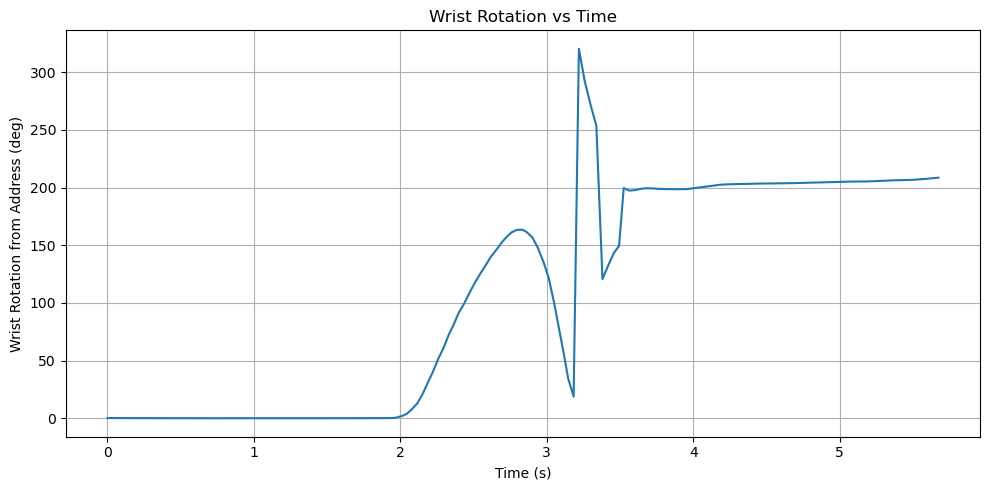

In [6]:
# Step 6: Plot full-session angle vs time

plt.figure(figsize=(10, 5))
plt.plot(df["time_s"], df["angle_deg"])
plt.xlabel("Time (s)")
plt.ylabel("Wrist Rotation from Address (deg)")
plt.title("Wrist Rotation vs Time")
plt.grid(True)
plt.tight_layout()
plt.show()

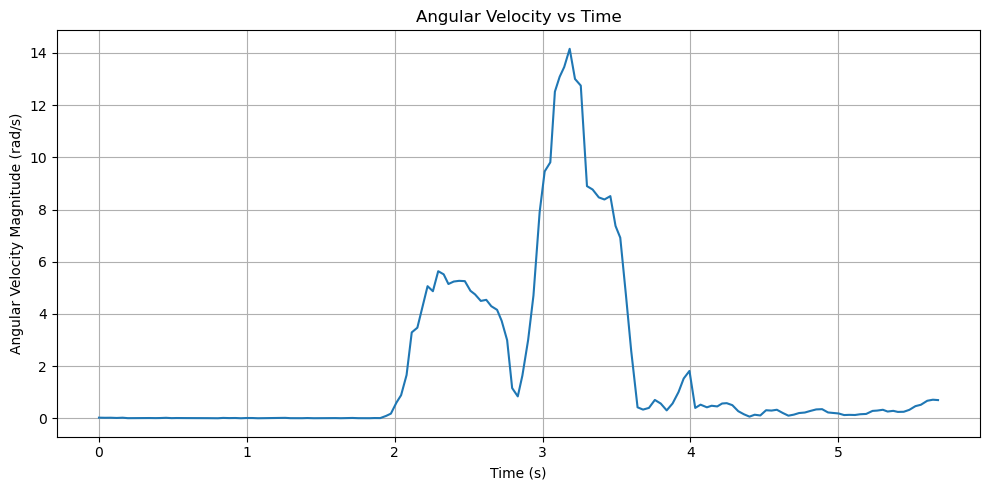

In [7]:
# Step 7: Plot full-session angular velocity vs time

plt.figure(figsize=(10, 5))
plt.plot(df["time_s"], df["gyro_mag"])
plt.xlabel("Time (s)")
plt.ylabel("Angular Velocity Magnitude (rad/s)")
plt.title("Angular Velocity vs Time")
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# Step 8: Detect swing automatically

max_gyro = df["gyro_mag"].max()
print("\nMax gyro magnitude:", max_gyro)

# Pick a threshold based on your data
# If your data is small, this keeps the threshold practical
start_threshold = max(0.05, 0.15 * max_gyro)

print("Using swing detection threshold:", start_threshold)

moving_indices = df.index[df["gyro_mag"] > start_threshold]

if len(moving_indices) == 0:
    raise ValueError(
        "No swing detected. Try moving more during the test or lowering the threshold."
    )

start_idx = moving_indices[0]
end_idx = moving_indices[-1]

# Add a little padding before/after detected movement
pad = 10
start_idx = max(0, start_idx - pad)
end_idx = min(len(df) - 1, end_idx + pad)

swing_df = df.iloc[start_idx:end_idx + 1].copy().reset_index(drop=True)

if len(swing_df) < 5:
    raise ValueError("Detected swing window is too small to analyze.")

swing_df["t_norm"] = np.linspace(0, 1, len(swing_df))

print("\nDetected swing window:")
print("Start time:", swing_df["time_s"].iloc[0])
print("End time:", swing_df["time_s"].iloc[-1])
print("Rows:", len(swing_df))


Max gyro magnitude: 14.156685210671776
Using swing detection threshold: 2.1235027816007666

Detected swing window:
Start time: 1.754
End time: 3.993
Rows: 62


In [9]:
# Step 9: Add target curve and deviation

swing_df["target_angle_deg"] = swing_df["t_norm"].apply(target_swing_curve)
swing_df["deviation_deg"] = swing_df["angle_deg"] - swing_df["target_angle_deg"]
swing_df["abs_deviation_deg"] = np.abs(swing_df["deviation_deg"])
swing_df["haptic_command"] = swing_df["abs_deviation_deg"].apply(haptic_level)

# Step 10: Find simple swing markers

top_idx = swing_df["angle_deg"].idxmax()
peak_idx = swing_df["gyro_mag"].idxmax()

print("\nSwing markers:")
print("Top of backswing at t =", swing_df.loc[top_idx, "time_s"], "s")
print("Peak angular velocity at t =", swing_df.loc[peak_idx, "time_s"], "s")


Swing markers:
Top of backswing at t = 3.219 s
Peak angular velocity at t = 3.183 s


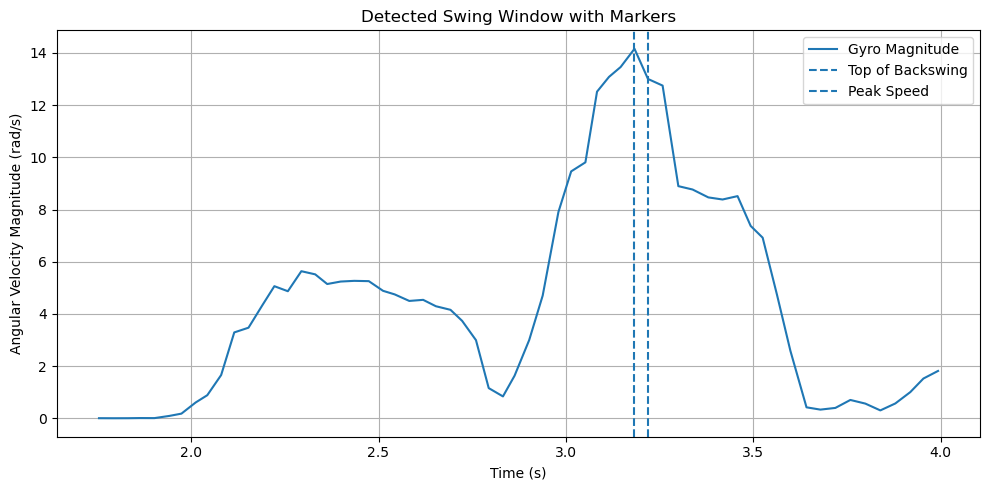

In [10]:
# Step 11: Plot swing phases on gyro graph

plt.figure(figsize=(10, 5))
plt.plot(swing_df["time_s"], swing_df["gyro_mag"], label="Gyro Magnitude")
plt.axvline(swing_df.loc[top_idx, "time_s"], linestyle="--", label="Top of Backswing")
plt.axvline(swing_df.loc[peak_idx, "time_s"], linestyle="--", label="Peak Speed")
plt.xlabel("Time (s)")
plt.ylabel("Angular Velocity Magnitude (rad/s)")
plt.title("Detected Swing Window with Markers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

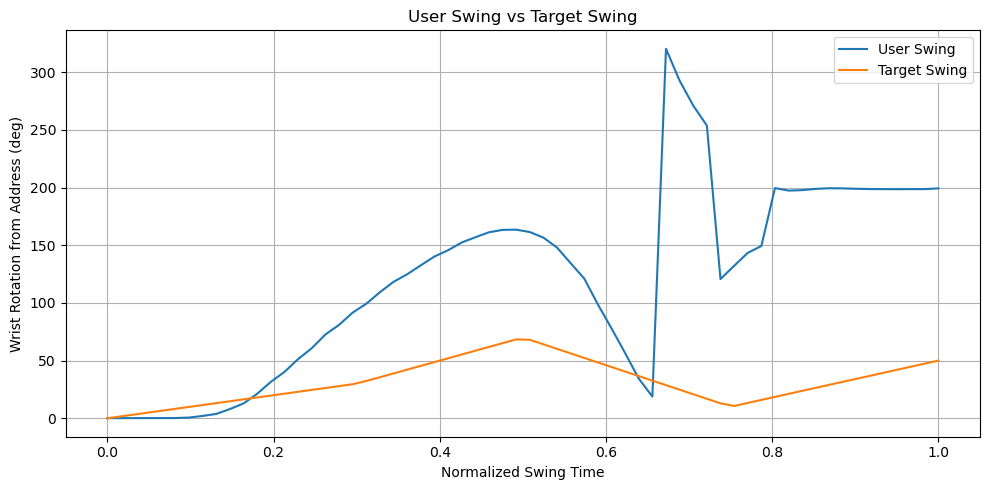

In [11]:
# Step 12: Plot user swing vs target

plt.figure(figsize=(10, 5))
plt.plot(swing_df["t_norm"], swing_df["angle_deg"], label="User Swing")
plt.plot(swing_df["t_norm"], swing_df["target_angle_deg"], label="Target Swing")
plt.xlabel("Normalized Swing Time")
plt.ylabel("Wrist Rotation from Address (deg)")
plt.title("User Swing vs Target Swing")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

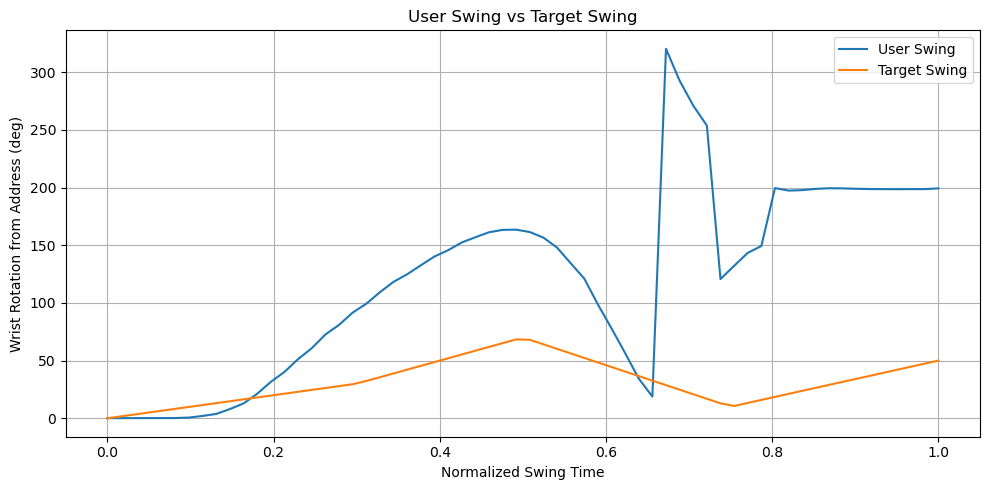

In [12]:
# Step 12: Plot user swing vs target

plt.figure(figsize=(10, 5))
plt.plot(swing_df["t_norm"], swing_df["angle_deg"], label="User Swing")
plt.plot(swing_df["t_norm"], swing_df["target_angle_deg"], label="Target Swing")
plt.xlabel("Normalized Swing Time")
plt.ylabel("Wrist Rotation from Address (deg)")
plt.title("User Swing vs Target Swing")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# Step 14: Print haptic preview

print("\nHaptic preview:")
print(swing_df[["time_s", "angle_deg", "target_angle_deg", "abs_deviation_deg", "haptic_command"]].head(20))


Haptic preview:
    time_s  angle_deg  target_angle_deg  abs_deviation_deg  haptic_command
0    1.754   0.103784          0.000000           0.103784               0
1    1.794   0.114222          1.639344           1.525122               0
2    1.832   0.124502          3.278689           3.154187               0
3    1.863   0.133171          4.918033           4.784862               0
4    1.902   0.142374          6.557377           6.415003               1
5    1.942   0.205149          8.196721           7.991572               1
6    1.974   0.600383          9.836066           9.235682               1
7    2.012   2.032805         11.475410           9.442605               1
8    2.043   3.767617         13.114754           9.347137               1
9    2.080   8.033080         14.754098           6.721019               1
10   2.115  12.871797         16.393443           3.521645               0
11   2.153  21.286728         18.032787           3.253941               0
12   2.1